<div style="text-align: justify;">

In this chapter, we will explore five commonly used examples in Bayesian inference. Each example is designed to show, step-by-step, how to calculate the posterior distribution, find the Bayesian estimate of the parameter, and compute the Mean Square Error (MSE) of the estimate.

These examples have been selected to clearly demonstrate how Bayesian methods work in practice for teaching purposes. By following these examples, one can gain a better understanding of how to apply Bayesian techniques and assess the accuracy of the estimates. The detailed calculations and used codes are included to make learning easier and more practical.

</div>

# Example - I (Poisson rate parameter with gamma prior)

<div style="text-align: justify;">


Let $X_1, X_2, \cdots, X_n$ be a random sample of size $n$ from a population following $\text{Poisson}(\lambda)$ distribution. Suppose $\lambda$ has a gamma$(\alpha,\beta)$ distribution, which is the conjugate family for Poisson. So, the statistical model has the following hierarchy:

$$
X_i \mid \lambda \sim \text{Poisson}(\lambda), \quad i = 1, 2, \cdots, n,
$$

$$
\lambda \sim \text{gamma}(\alpha, \beta).
$$

Based on the observed sample, we are interested to estimate the mean of the population, that is the value of $\lambda$. The prior distribution of $\lambda$, $\pi(\lambda)$, is given by

$$
\pi(\lambda) = \frac{\lambda^{\alpha - 1} e^{-\lambda / \beta}}
{\Gamma(\alpha)\,\beta^\alpha}, \qquad \lambda > 0,
$$

where $\alpha$ and $\beta$ are positive constants. First, we shall obtain the posterior distribution of $\lambda$. If there were no prior information available about the parameter $\lambda$, then we could use the sample mean $\overline{X}$ to estimate it. However, the exact sampling distribution of $\overline{X}$ is not known in this case. Therefore, we begin with a statistic $Y = \sum_{i=1}^n X_i,$
whose sampling distribution is known to be $\text{Poisson}(n\lambda)$ (denoted by $f(y \mid \lambda)$). The posterior distribution, the conditional distribution of $\lambda$ given the sample $X_1, X_2, \cdots, X_n$, that is, given $Y = y$, is

$$
\pi(\lambda \mid y) = \frac{f(y \mid \lambda)\,\pi(\lambda)}{m(y)}.
$$

where $m(y)$ is the marginal distribution of $Y$ and can be calculated as follows:

$$
\begin{aligned}
m(y) 
    &= \int_0^\infty f(y \mid \lambda)\,\pi(\lambda)\,d\lambda \\[6pt]
    &= \int_0^\infty 
        \frac{e^{-n\lambda}(n\lambda)^y}{y!} \cdot 
        \frac{\lambda^{\alpha - 1} e^{-\lambda/\beta}}{\Gamma(\alpha)\beta^\alpha} \, d\lambda \\[6pt]
    &= \frac{n^y}{y!\,\Gamma(\alpha)\beta^\alpha}
        \int_0^\infty e^{-\lambda\left(n + \frac{1}{\beta}\right)}\,
        \lambda^{y + \alpha - 1}\, d\lambda \\[6pt]
    &= \frac{n^y\,\Gamma(y+\alpha)}{y!\,\Gamma(\alpha)\beta^\alpha 
        \left(y + \frac{1}{\beta}\right)^{y+\alpha}}
        \int_0^\infty 
        \frac{ e^{-\lambda\left(n + \frac{1}{\beta}\right)} \lambda^{y+\alpha - 1}}
        {\Gamma(y+\alpha)}\,
        \left(n + \frac{1}{\beta}\right)^{y+\alpha}\,
        d\lambda \\[6pt]
    &= \frac{n^y\,\Gamma(y+\alpha)}
        {y!\,\Gamma(\alpha)\beta^\alpha 
        \left(n + \frac{1}{\beta}\right)^{y+\alpha}},
        \qquad y = 0,1,2,\dots
\end{aligned}
$$

In the above, the integrand is the kernel of the gamma  $\gamma\left(y+\alpha,\; \left(n + \frac{1}{\beta}\right)^{-1}\right)$
density function, which integrates to 1.Now, the posterior density $\pi(\lambda \mid y)$ is given by

$$
\begin{aligned}
\pi(\lambda \mid y)
    &= \frac{
        \frac{e^{-n\lambda}(n\lambda)^y}{y!}
        \cdot 
        \frac{\lambda^{\alpha-1} e^{-\lambda/\beta}}
        {\Gamma(\alpha)\beta^\alpha}
        \cdot
        \frac{y!\,\Gamma(\alpha)\beta^\alpha \left(n+\frac{1}{\beta}\right)^{y+\alpha}}
        {n^y\,\Gamma(y+\alpha)}
        }
        { } \\[8pt]
    &= \frac{\left(n+\frac{1}{\beta}\right)^{y+\alpha}}
        {\Gamma(y+\alpha)}
        \lambda^{y+\alpha-1}
        e^{-\lambda\left(n+\frac{1}{\beta}\right)},
        \qquad 0 < \lambda < \infty.
\end{aligned}
$$


Hence, as expected, the posterior distribution of $\lambda$,

$$
\lambda \mid y \sim \text{gamma}\left( y + \alpha,\; \left( n + \frac{1}{\beta} \right)^{-1} \right).
$$

It also verifies the claim that the gamma$(\alpha,\beta)$ is the conjugate family for Poisson. A closure look in the above calculations reveals that the steps can be heavily reduced, in fact the explicit expression for $m(y)$ is not at all required. Since, it does not depend of $\lambda$, it is a constant, that makes the integral $\int_{0}^{\infty} \pi(\lambda \mid y)d\lambda$ to be equal to $1$, so that it becomes a valid probability density function. Thus, appearance of the posterior density in the integrand of the marginal is not a magic. We shall use this posterior distribution of $\lambda$ to make statements about the parameter $\lambda$. The mean of the posterior can be used as a point estimate of $\lambda$. So, the Bayesian estimator of $\lambda$ (call it $\hat{\lambda}_{B}$) is given by $E(\lambda \mid Y)$. Because of the gamma density, we avoid the computation of the integral and directly write as:

$$
\hat{\lambda}_{B}
= \frac{y + \alpha}{\,n + \frac{1}{\beta}\,}
= \frac{\beta(y+\alpha)}{n\beta + 1}.
$$

Let us investigate the structure of the Bayesian estimate of $\lambda$. If no data were available, we are forced to use the information from the prior distribution (only). $\pi(\lambda)$ has the mean $\alpha\beta$, which would be our best estimate of $\lambda$. If no prior information were available, we would use $Y/n$ (sample mean $\overline{X}$) to estimate $\lambda$ and draw the conclusion based on the sample values only. Now, the beautiful part is that the Bayesian estimator combines all of these information (if available). We can write $\hat{\lambda}_{B}$ in the following way.

$$
\hat{\lambda}_{B}
=
\left( \frac{n\beta}{n\beta + 1} \right)
\left( \frac{Y}{n} \right)
+
\left( \frac{1}{n\beta + 1} \right)
(\alpha\beta).
$$


Thus $\hat{\lambda}_{B}$ is a linear combination of the prior mean and the sample mean. The weights are determined by the values of $\alpha$, $\beta$ and $n$.

Suppose that we increase the sample size such that $n \rightarrow \infty$. Then $\frac{n\beta}{n\beta + 1} \rightarrow 1$ and $\frac{1}{n\beta + 1} \rightarrow 0$, and $\hat{\lambda}_{B} \rightarrow \overline{X}$. The idea is that as we increase the sample size, the data histogram closely approximates the population distribution itself. As if we have got enough knowledge about the population itself (because of a large number of observations). Hence, the prior information becomes less relevant and the value of the sample mean dominates the Bayesian estimate of $\lambda$. When the size of the sample is small, then it is wise to utilize the prior information about the population parameter. Hence, the term $\left( \frac{\alpha\beta}{n\beta + 1} \right)$ contributes significantly in the final estimate. By weak law of large numbers $\overline{X} \rightarrow \lambda$ in probability as $n \rightarrow \infty$, so $\hat{\lambda}_{B} \rightarrow \theta$ in probability, proving that $\hat{\lambda}_{B}$ is consistent estimator for $\lambda$. Another interesting point is that, for any finite $n$, $\hat{\lambda}_{B}$ is a biased estimator of $\lambda$, with $\mathrm{Bias}_{\lambda}(\hat{\lambda}_{B}) = \frac{\alpha\beta - \lambda}{n\beta + 1} \rightarrow 0$ as $n \rightarrow \infty$. $\hat{\lambda}_{B}$ is asymptotically unbiased.

We end up with two estimators for the parameter $\lambda$, viz. Bayesian estimate, $\hat{\lambda}_{B}$ and Maximum likelihood estimator $\hat{\lambda} = \overline{X}$. It is natural to ask which estimator should we prefer? The efficiency of an estimator is computed by the Mean Square Error (MSE) which measures the average squared difference between the estimator and the parameter. In the present situation, the MSE of $\hat{\lambda}$ is

$$
E_{\lambda}(\hat{\lambda} - \lambda)^{2}
= \mathrm{Var}_{\lambda}(\overline{X})
= \frac{\lambda}{n}.
$$


Since, $\overline{X}$ is an unbiased estimator of $\lambda$, the MSE of $\overline{X}$ is equal to its variance. Now, given $Y = \sum_{i=1}^{n} X_{i}$, the MSE of the Bayesian estimator of $\lambda$, $\hat{\lambda}_{B} = \frac{\beta (Y + \alpha)}{n\beta + 1}$, is

\begin{align*}
E_{\lambda}(\hat{\lambda}_{B} - \lambda)^{2}
&= \mathrm{Var}_{\lambda}\hat{\lambda}_{B} + (\mathrm{Bias}_{\lambda}\hat{\lambda}_{B})^{2} \\
&= \mathrm{Var}_{\lambda}\left( \frac{\beta (Y + \alpha)}{n\beta + 1} \right)
+ \left( E_{\lambda}\left( \frac{\beta (Y + \alpha)}{n\beta + 1} \right) - \lambda \right)^{2} \\
&= \frac{\beta^{2} n \lambda}{(n\beta + 1)^{2}}
+ \frac{(\alpha\beta - \lambda)^{2}}{(n\beta + 1)^{2}}.
\end{align*}

For fixed $n$, the above quantity will be minimum if $\alpha\beta = \lambda$, that is the prior mean is equal to the true value. However, in general, MSE is a function of the parameter. So, it is highly unlikely that we would end up with a single estimator which is the best for all parameter values. In general the MSEs of two estimators cross each other. This demonstrates that one estimator is better with respect to another estimator in only a portion of the parameter space. Now let us delve deep further in comparing the above two estimators. If $\lambda = \alpha\beta$, then for large $n$,

$$
\mathrm{MSE}_{\lambda}(\hat{\lambda}_{B})
= \frac{\beta^{2} n \lambda}{(n\beta + 1)^{2}}
= \frac{\beta^{2} n \lambda}{n^{2} \beta^{2} \left(1 + \frac{1}{n\beta}\right)^{2}}
\approx \frac{\lambda}{n}.
$$

Thus, if the prior is chosen in such way (choice of $\alpha$ and $\beta$) so that the prior mean is close to the true value, then both the estimators have same variance approximately, for large $n$. This observation is depicted in Figure 2.1. We consider the values of $\alpha$ and $\beta$ to be $4$ and $\frac{1}{2}$, respectively, so that the prior mean is $\alpha\beta = 2$. It is clear from the figure that if prior mean is close to the true value, then $\hat{\lambda}_{B}$ performs better than $\hat{\lambda}$. If the prior mean is much away from the true value, then $\hat{\lambda}$ performs better than $\hat{\lambda}_{B}$. However, for large sample size ($n \rightarrow \infty$) both the estimators have same MSE.

</div>

In [1]:
using Plots, Statistics, StatsBase
using LaTeXStrings, Distributions, Random
using KernelDensity, SpecialFunctions

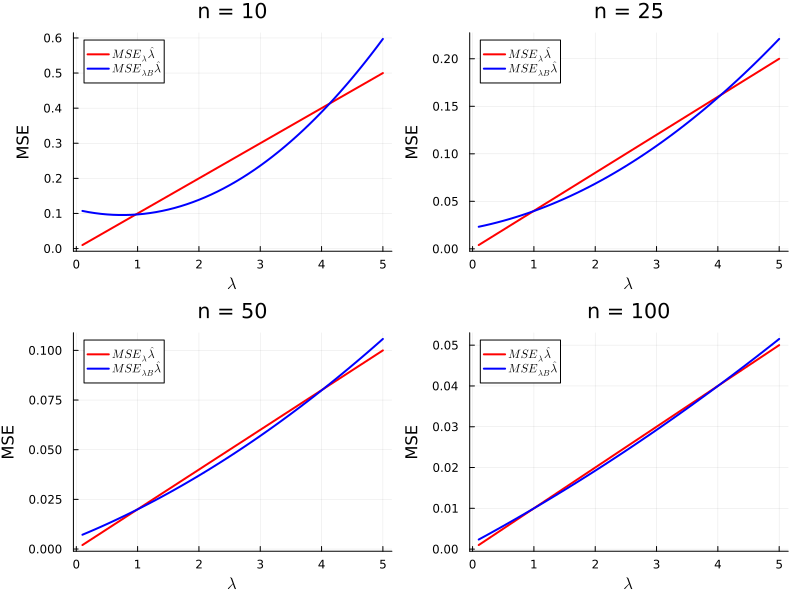

In [2]:
plt = plot(layout = (2, 2), size = (800, 600))
α = 4
β = 1/2
λ = range(0.1, 5, length = 50)

n_vals = [10, 25, 50, 100]

for (idx, n) in enumerate(n_vals) 
    mse_λ_cap = λ ./n
    mse_λB_cap = (β^2*n .*λ .+ (α*β .- λ) .^2) ./(n*β + 1)^2
    plot!(λ, mse_λ_cap, color = "red", lw = 2, xlabel = L"λ", ylabel = "MSE", 
        label = L"MSE_{λ}\hat{λ}", subplot = idx, title = "n = $n")
    plot!(λ, mse_λB_cap, color = "blue", lw = 2, label = L"MSE_{λB}\hat{λ}",
        subplot = idx)
end
display(plt)

<div style="text-align: justify;">


Figure: MSE of $\hat{\lambda} = \bar{X}$ and $\hat{\lambda}_B$ at different values of $\lambda$ for different choices of the sample size, $n$. The prior distribution of $\lambda$ is chosen as $\text{gamma}(4, \frac{1}{2})$. The prior mean is 2 and is indicated by a black dot. For small sample size $n = 10$, the $\text{MSE}_{\lambda}(\hat{\lambda}_B)$ is lower than the $\text{MSE}_{\lambda}(\hat{\lambda})$ for all true values of $\lambda$ in a neighborhood of 2. As $\lambda$ increases, after a certain value, $\text{MSE}_{\lambda}(\hat{\lambda})$ crosses the MSE of $\hat{\lambda}$. The same is observed for very small values of $\lambda$. However, for large $n$ values, the MSE of both the estimators merges, essentially the prior information becomes redundant ($n = 50$).

</div>


<div style="text-align: justify;">


We have seen that the posterior mean is a linear combination of prior mean and the sample mean. Basically, the Bayesian estimate lies between the sample mean and prior mean. That is, the linear combination is in fact a convex combination. This can also be better visualized if we plot the three distributions in a single plot window, viz. the data histogram, prior distribution, posterior distribution

</div>

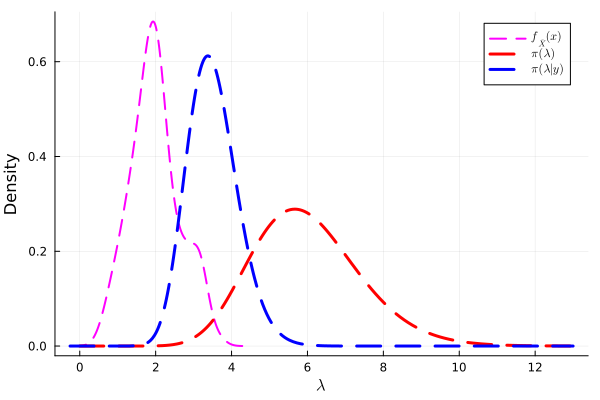

In [3]:
n = 5  # sample size
λ = 2  # true mean value
Random.seed!(123)
rep = 100
mean_vals = zeros(rep)
for i in 1:rep 
    mean_vals[i] = mean(rand(Poisson(λ), n))
end
d = kde(mean_vals)  # compute kernel density
plot(d.x, d.density, color = "magenta", lw = 2, ls = :dash, xlabel = L"λ", 
    ylabel = "Density", label = L"f_{\bar{X}}(x)")
α = 18
β = 1/3  # hyperparameters
prior_density(x) =  exp(-x/β)*x^(α-1)/(β^α * gamma(α))
plot!(prior_density, 0, 13, color = "red", lw = 3, ls = :dash, label = L"π(λ)")
y = sum(rand(Poisson(λ), n))  # sufficient statistics
function posterior_density(x)
    (n+1/β)^(y+α)*exp(-x*(n+1/β))*x^(y+α-1)/gamma(y+α)
end
plot!(posterior_density, color = "blue", lw = 3, ls = :dash, label = L"π(λ|y)")

<div style="text-align: justify;">


Figure: A sample of size $n = 5$ were simulated from the Poisson distribution with parameter $\lambda = 2$ and the sample mean has been computed. The process has been replicated 100 times to obtain the sampling distribution of the sample mean and approximated by a kernel density estimator (magenta colour). The maximum likelihood estimate of $\lambda$ is denoted by magenta coloured `*`. Similarly exact prior density and exact posterior density functions are plotted using blue and red colour, respectively. Similarly the prior mean and posterior mean values are also marked. The depicted picture clearly verifies the theoretical calculations performed in the text.

</div>

# Example - II (Normal prior for normal mean)

<div style="text-align: justify;">


Suppose we observe a sample of size 1, $X \sim \mathcal{N}(\theta, \sigma^2)$ and suppose that the prior distribution of $\theta$ is $\mathcal{N}(\mu, \tau^2)$. We assume that the quantities, $\sigma^2, \mu$ and $\tau^2$ are all known. We are interested to obtain the posterior distribution of $\theta$. The prior distribution is given as;

$$
\pi(\theta) = \frac{1}{\tau \sqrt{2\pi}} e^{-\frac{(\theta - \mu)^2}{2\tau^2}}, 
\qquad -\infty < \mu,\, \theta < \infty,\; 0 < \tau < \infty.
$$

The posterior density function of $\theta$ is given as follows;

$$
\pi(\theta \mid x)
= \frac{ f(x \mid \theta)\,\pi(\theta) }{ \int_{-\infty}^{\infty} f(x \mid \theta)\,\pi(\theta)\, d\theta }
$$

$$
= \frac{ \frac{1}{\sigma\tau(\sqrt{2\pi})^2} 
\exp\left\{
-\frac{1}{2}
\left[
\left(\frac{x-\theta}{\sigma}\right)^2
+
\left(\frac{\theta-\mu}{\tau}\right)^2
\right]
\right\}}
{\int_{-\infty}^{\infty} f(x \mid \theta)\,\pi(\theta)\, d\theta } .
$$

The exponent can be expressed as

$$
\frac{\sigma^2 + \tau^2}{\sigma^2 \tau^2}
\left[
\left(
\theta - \frac{x\tau^2 + \mu\sigma^2}{\sigma^2 + \tau^2}
\right)^2
\;+\;
\frac{\tau^2 x^2 + \mu^2 \sigma^2}{\sigma^2 + \tau^2}
\;-\;
\left(
\frac{x\tau^2 + \mu\sigma^2}{\sigma^2 + \tau^2}
\right)^2
\right].
$$

Note that, all the terms except containing the expression of $\theta$ will be cancelled with the denominator, resulting the posterior density of $\theta$ given as follows;

$$
\pi(\theta \mid x)
= \frac{\sqrt{\sigma^2 + \tau^2}}{\sigma \tau \sqrt{2\pi}}
\exp\left[
-\frac{\sigma^2 + \tau^2}{2\sigma^2 \tau^2}
\left(
\theta - \frac{x\tau^2 + \mu\sigma^2}{\sigma^2 + \tau^2}
\right)^2
\right].
$$


The posterior distribution of $\theta$ is normal, showing that the normal family is its own conjugate when indexed by the mean $(\theta)$. The posterior mean and variance of $\theta$ are as follows;

$$
\mathbb{E}(\theta \mid x)
= \frac{x\tau^2 + \mu\sigma^2}{\sigma^2 + \tau^2},
\qquad \text{and} \qquad
\mathrm{Var}(\theta \mid x)
= \frac{\sigma^2 \tau^2}{\sigma^2 + \tau^2}.
$$

As discussed earlier, $\mathbb{E}(\theta \mid x)$ is a point estimate of $\theta$, thus the Bayesian estimator of $\theta$ based on a single sample is given by

$$
\hat{\theta}_B
= \frac{X\tau^2 + \mu\sigma^2}{\sigma^2 + \tau^2}
= \left( \frac{\tau^2}{\sigma^2 + \tau^2} \right) X
+ \left( \frac{\sigma^2}{\sigma^2 + \tau^2} \right) \mu.
$$

Again, the Bayesian estimate of $\theta$ is a linear combination of the prior mean and the sample value (which is in fact the estimate of $\theta$, as the size of the sample is 1). We shall treat this problem based on a sample of size $n$ and obtain the Bayesian estimator of $\theta$ using it. A tedious calculation is required to obtain the posterior distribution. However, that will help us to obtain the distribution of $\theta \mid \overline{X}$ easily. Suppose that we draw a sample $X_1, X_2, \cdots, X_n$ of size $n$ from $\mathcal{N}(\theta, \sigma^2)$, then the sample mean $\overline{X} \sim \mathcal{N}(\theta, \sigma^2/n)$. The same calculation will follow with $X$ would be replaced by $\overline{X}$ and $\sigma^2$ will be replaced by $\sigma^2/n$, respectively. Then the posterior distribution of $\theta$ is normal, with mean and variance given by

$$
\mathbb{E}(\theta \mid \overline{x})
= \frac{\overline{x} n \tau^2 + \mu \sigma^2}{\sigma^2 + n\tau^2},
\qquad
\mathrm{Var}(\theta \mid \overline{x})
= \frac{\sigma^2 \tau^2}{\sigma^2 + n\tau^2}.
$$

and the Bayesian estimator is given as follows;

$$
\hat{\theta}_B
= \left( \frac{n\tau^2}{\sigma^2 + n\tau^2} \right)\overline{X}
+ \left( \frac{\sigma^2}{\sigma^2 + n\tau^2} \right)\mu.
$$

As $n \to \infty$,  $\displaystyle \frac{n\tau^2}{\sigma^2 + n\tau^2} \to 1$  and  $\displaystyle \frac{\sigma^2}{\sigma^2 + n\tau^2} \to 0$, so that $\hat{\theta}_B \approx \overline{X}$.But, when $n$ is small, use of prior information improves the estimator.  Since, $\overline{X} \to \theta$ in probability as $n \to \infty$, which follows that $\hat{\theta}_B \to \theta$ in probability as $n \to \infty$  (By Slutsky’s theorem).  

MSE of $\hat{\theta}_B$ is given by

$$
\mathbb{E}_\theta (\hat{\theta}_B - \theta)^2
= \operatorname{Var}_\theta(\hat{\theta}_B)
+ \left( \operatorname{Bias}_\theta(\hat{\theta}_B) \right)^2
$$

Using the expressions of the Bayesian estimator:

$$
\begin{aligned}
\mathbb{E}_\theta(\hat{\theta}_B - \theta)^2
&= \mathrm{Var}_\theta(\hat{\theta}_B)
+ \left( \mathrm{Bias}_\theta(\hat{\theta}_B) \right)^2 \\[6pt]
&= \mathrm{Var}_\theta \left(
\frac{\overline{X} n \tau^2 + \mu\sigma^2}{\sigma^2 + n\tau^2}
\right)
+ \left(
\mathbb{E}_\theta \left(
\frac{\overline{X} n \tau^2 + \mu\sigma^2}{\sigma^2 + n\tau^2}
\right)
- \theta
\right)^2 \\[6pt]
&= \frac{\tau^4 n\sigma^2}{(\sigma^2 + n\tau^2)^2}
+ \frac{(\mu - \theta)^2\sigma^4}{(\sigma^2 + n\tau^2)^2} \\[6pt]
&= \frac{\sigma^2}{(\sigma^2 + n\tau^2)^2}
\left( n\tau^4 + (\mu - \theta)^2 \sigma^2 \right).
\end{aligned}
$$


The estimators $\hat{\theta}_B$ and $\overline{X}$ are compared for different sample sizes and also for different choices of the prior variance $\tau^2$. The estimator can also be compared by using the relative efficiency, which is defined as the MSE of the two estimators. So the efficiency of $\hat{\theta}_B$ relative to $\overline{X}$, $\text{eff}_\theta(\hat{\theta}_B \mid \overline{X})$, is

$$
\begin{aligned}
\text{eff}_\theta(\hat{\theta}_B \mid \overline{X})
  &= \frac{\text{MSE}_\theta(\hat{\theta}_B)}{\text{MSE}_\theta(\overline{X})} \\
  &= \frac{n \tau^4 + (\mu - \theta)^2 \sigma^2}{(\sigma^2 + n \tau^2)^2}.
\end{aligned}
$$

If $\mu = \theta$, for a given sample size $n$, relative efficiency is minimum and less than 1. Hence, $\hat{\theta}_B$ is more efficient than $\overline{X}$ for any given $n$. If we move $\theta$ values away from $\mu$, then $\text{eff}_\theta(\hat{\theta}_B \mid \overline{X})$ crosses the line $y = 1$. For theta values beyond that point, $\overline{X}$ is better than $\hat{\theta}_B$. We encourage the reader to draw this picture and compare two estimators based on the relative efficiency. It is clearly understood that, essentially, we are describing the same thing, only with a different graphical representation. Of course, the plotting tools in Julia (for example `Plots.jl`) provide a convenient way to draw this curve.

</div>



In [4]:
using Plots, Statistics, StatsBase
using LaTeXStrings, Distributions, Random
using KernelDensity, SpecialFunctions

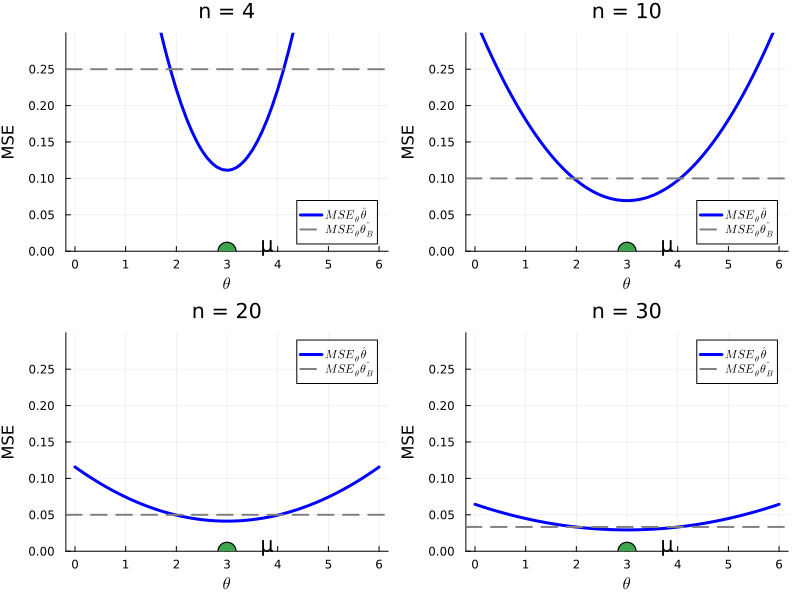

In [5]:
σ = sqrt(1)  # population sd
μ = 3  # prior mean value
τ = sqrt(0.5)  # prior sd
n_vals = [4, 10, 20, 30]
plt = plot(layout = (2, 2), size = (800, 600))
for (idx, n) in enumerate(n_vals) 
    plot!(x->(σ^2/(σ^2 + n*τ^2)^2*(n*τ^4 + (μ-x)^2*σ^2)), 0, 6, 
        color = "blue", lw = 3, xlabel = L"θ", ylabel = "MSE", 
        title = "n = $n", ylims = (0, 0.3), label = L"MSE_{θ}\hat{θ}", 
        subplot = idx)
    hline!([σ^2/n], color = "grey", lw = 2, label = L"MSE_{θ}\hat{θ_B}", 
        ls = :dash,subplot = idx)
    scatter!([μ],[0], markersize = 10, subplot = idx, label = "")
    annotate!(μ + 0.8, 0.01, "μ", subplot = idx)
end
display(plt)

<div style="text-align: justify;">

Figure: $\mathrm{MSE}_\theta(\hat{\theta})$ and $\mathrm{MSE}_\theta(\hat{\theta}_B)$ are plotted as a function of $\theta$ for different sample size $n$. The prior distribution of $\theta$ is considered to be $\mathcal{N}(\mu = 3, \tau^2 = 0.5)$. The prior mean $\mu$ is indicated by a black dot. For sample size, $n = 4$, $\mathrm{MSE}_\theta(\hat{\theta}_B)$ is smaller than $\mathrm{MSE}_\theta(\hat{\theta})$ at all values of $\theta$ in a neighborhood of $\mu$. As we move away from $\mu$, $\hat{\theta}$ is more preferable outside the neighborhood of $\mu$. However, as we increase $n$, MSE of both the estimators become closer in every neighborhood of $\mu$ ($n = 20$), reducing the impact of prior information.

</div>

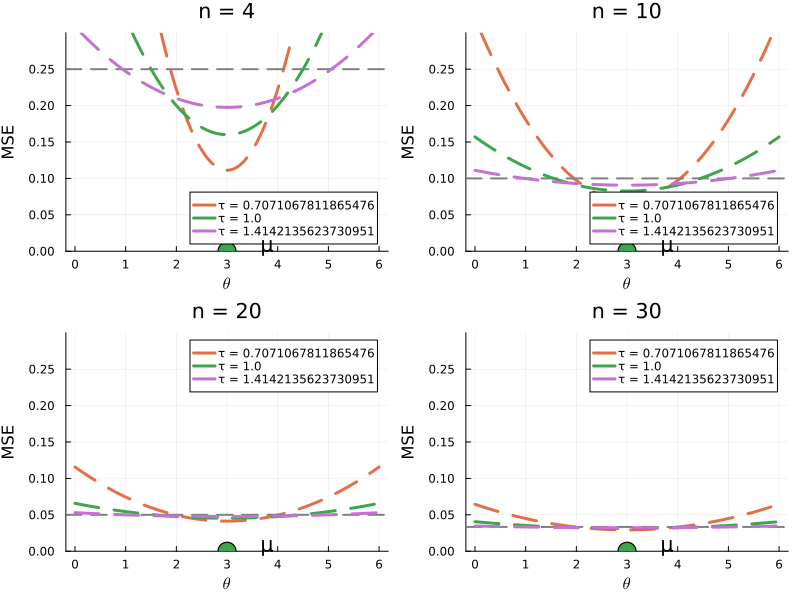

In [6]:
plt = plot(layout = (2, 2), size = (800, 600))
n_vals = [4, 10, 20, 30]
σ = sqrt(1)
τ_vals = sqrt.([0.5, 1, 2])

for (idx, n) in enumerate(n_vals) 
    for i in 1:length(τ_vals)
        τ = τ_vals[i]
        if i == 1
            plot!(x->(σ^2/(σ^2 + n*τ^2)^2*(n*τ^4 + (μ-x)^2*σ^2)), 0, 6, 
            color = i + 1, lw = 3, xlabel = L"θ", ylabel = "MSE", 
            title = "n = $n", ylims = (0, 0.5), label = "τ = $τ", 
            subplot = idx, ls = :dash)
            hline!([σ^2/n], color = "grey", lw = 2, label = "", 
            ls = :dash,subplot = idx)
            scatter!([μ],[0], markersize = 10, subplot = idx, label = "")
            annotate!(μ + 0.8, 0.01, "μ", subplot = idx)
        else
            plot!(x->(σ^2/(σ^2 + n*τ^2)^2*(n*τ^4 + (μ-x)^2*σ^2)), 0, 6, 
            color = i + 1, lw = 3, xlabel = L"θ", ylabel = "MSE", 
            title = "n = $n", ylims = (0, 0.3), label = "τ = $τ", 
            subplot = idx, ls = :dash)
        end
    end
end

display(plt)


<div style="text-align: justify;">


Figure: The MSE of the two estimators are compared at different values of $\tau^2$. For small sample size ($n = 4$) and small $\tau^2 < \sigma^2$, $\hat{\theta}_B$ performs better than $\hat{\theta}$. For large values of $\tau^2 > \sigma^2$, $\mathrm{MSE}_\theta(\hat{\theta}_B)$ increases. Basically, prior information becomes vague for large $\tau^2$ values. As expected, for large sample size ($n = 20$) both the estimators perform at par irrespective of the prior variance.

</div>

# Example - III (Beta prior for Bernoulli($p$))

<div style="text-align: justify;">


Let $X_1, X_2, \cdots, X_n$ be iid Bernoulli$(p)$. Then $Y = \sum_{i=1}^n X_i$ is binomial$(n,p)$. We assume the prior distribution of $p$ is $\mathrm{Beta}(\alpha, \beta)$. Then the joint distribution of $Y$ and $p$ is given by  

$$
\begin{aligned}
f(y,p) 
&= \binom{n}{y} p^y (1-p)^{\,n-y} 
     \left[ \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}
     p^{\,\alpha-1}(1-p)^{\,\beta-1} \right] \\
&= \binom{n}{y} \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}
     p^{\,y+\alpha-1}(1-p)^{\,n-y+\beta-1}.
\end{aligned}
$$

The marginal pdf of $Y$ is  

$$
\begin{aligned}
f(y) 
&= \int_0^1 f(y,p)\,dp \\
&= \binom{n}{y} \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}
   \frac{\Gamma(y+\alpha)\Gamma(n-y+\beta)}{\Gamma(n+\alpha+\beta)},
\end{aligned}
$$

which is the beta-binomial distribution. The posterior distribution of $p$ is given as follows:

$$
\begin{aligned}
\pi(p \mid y)
&= \frac{f(y,p)}{f(y)} \\
&= \frac{\Gamma(n+\alpha+\beta)}{\Gamma(y+\alpha)\Gamma(n-y+\beta)}
   p^{\,y+\alpha-1}(1-p)^{\,n-y+\beta-1},
\end{aligned}
$$

which is $\mathrm{Beta}(y+\alpha,\, n-y+\beta)$. So, the Bayes estimator of $p$ under squared–error loss is the posterior mean:

$$
\hat{p}_B = \frac{y+\alpha}{\alpha+\beta+n}.
$$


We can write $\hat{p}_B$ in the following way:

$$
\hat{p}_B 
= \left( \frac{n}{\alpha+\beta+n} \right)\left( \frac{Y}{n} \right)
+ \left( \frac{\alpha+\beta}{\alpha+\beta+n} \right)\left( \frac{\alpha}{\alpha+\beta} \right).
$$

Thus $\hat{p}_B$ is a linear combination of the prior mean and the sample mean. The weights are determined by the values of $\alpha,\beta$, and $n$. In the present situation, the MSE of $\hat{p}$ is

$$
E_p(\hat{p}-p)^2
= \operatorname{Var}(\bar{X})
= \frac{p(1-p)}{n}.
$$

Since $\bar{X}$ is an unbiased estimator of $p$, the MSE equals the variance. Given $Y = \sum_{i=1}^n X_i$, the MSE of the Bayesian estimator  $\hat{p}_B = \frac{Y+\alpha}{\alpha+\beta+n}$ is

$$
\begin{aligned}
E_p(\hat{p}_B - p)^2 
&= \operatorname{Var}_p(\hat{p}_B)
+ \left( \operatorname{Bias}_p\hat{p}_B \right)^2 \\[6pt]
&= \operatorname{Var}_p\!\left( \frac{Y+\alpha}{\alpha+\beta+n} \right)
+ \left( E_p\!\left( \frac{Y+\alpha}{\alpha+\beta+n} \right) - p \right)^2 \\[6pt]
&= \frac{n\,p(1-p)}{(\alpha+\beta+n)^2}
+ \frac{(\alpha - p(\alpha+\beta))^2}{(\alpha+\beta+n)^2}.
\end{aligned}
$$

</div>

In [7]:
using Plots, Statistics, StatsBase
using LaTeXStrings, Distributions, Random
using KernelDensity, SpecialFunctions

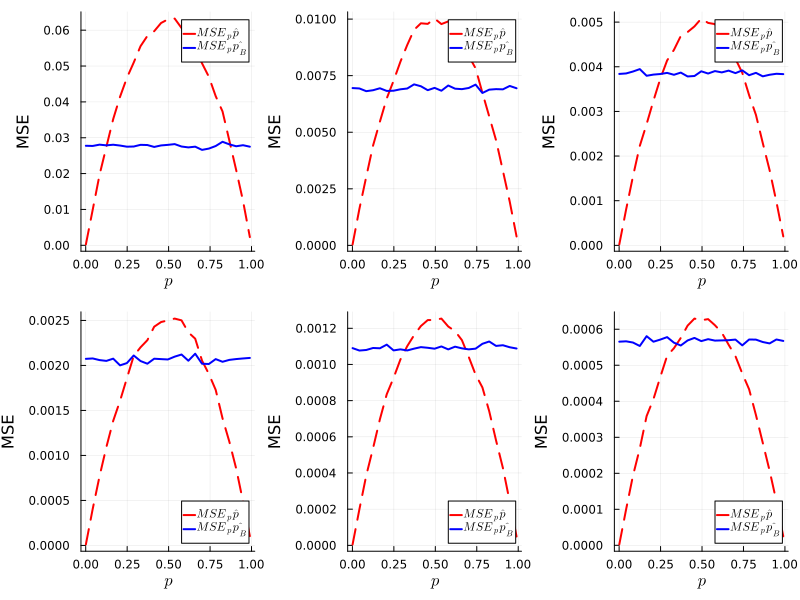

In [8]:
plt = plot(layout = (2, 3), size = (800, 600))

n_vals = [4, 25, 50, 100, 200, 400]
rep = 10^4
p = range(0.001, 0.99, length = 25)

for (idx, n) in enumerate(n_vals) 
    α = sqrt(n/4)
    β = sqrt(n/4)
    mse_p_cap = zeros(length(p))
    mse_pB_cap = zeros(length(p))
    for i in 1:length(p)
        p_cap = zeros(rep)
        pB_cap = zeros(rep)
        for j in 1:rep 
            d = rand(Bernoulli(p[i]), n)
            p_cap[j] = sum(d)/n
            pB_cap[j] = (sum(d) + α)/(α + β + n )
        end
        mse_p_cap[i] = mean((p_cap .- p[i]) .^2)
        mse_pB_cap[i] = mean((pB_cap .- p[i]) .^2)
    end
    plot!(p, mse_p_cap, color = "red", lw = 2, xlabel = L"p", 
        ylabel = "MSE", ls = :dash, label = L"MSE_{p}\hat{p}", 
        subplot = idx)
    plot!(p, mse_pB_cap, color = "blue", lw = 2, label = L"MSE_{p}\hat{p_B}", 
        subplot = idx)
end
display(plt)


<div style="text-align: justify;">


Figure: $\mathrm{MSE}_p(\hat{p}) = \mathrm{MSE}_p(\bar{X}) = \frac{p(1-p)}{n}$ and $\mathrm{MSE}_p(\hat{p}_B) = \frac{np(1-p)+[\alpha - p(\alpha+\beta)]^{2}}{(\alpha+\beta+n)^2}$ are computed based on simulated data from a $\mathrm{Bin}(n,p)$ distribution. The prior distribution $\pi(p)$ is assumed to be $\mathrm{Beta}(\alpha,\beta)$. Here we consider $\alpha=\beta=\sqrt{\frac{n}{4}}$ so that $\mathrm{MSE}(\hat{p}_B) = \frac{n}{4(n+\sqrt{n})^2}$, which is constant for all values of $p \ (0<p<1)$, for fixed $n$. The computation was done for different sample sizes as depicted in the figure. At each value of $p$, average MSEs of both the estimators were computed using 1000 replications. The MSEs are plotted against different values of $p$. For small sample size $n=4$, $\hat{p}_B$ has more precision in estimating the true proportion than $\hat{p}$ for almost all $p\in(0,1)$ except the values closer to 0 and 1, where $\hat{p}$ is better. However, as sample size increases, the interval in which $\hat{p}_B$ is better than $\hat{p}$ decreases substantially. For $n=400$, $\hat{p}_B$ works better in a very small interval about 0.5.

<div>

# Example - IV (Generalization of Hierarchical Bayes)

<div style="text-align: justify;">


We examine a generalization of the Hierarchical Bayes model. Let $X_1, X_2, \ldots, X_n$ be an observed random sample of size $n$ such that

$$
X_i \mid \lambda_i \sim \text{Poisson}(\lambda_i), \qquad i = 1,2,\ldots,n,\ \text{independent}.
$$

Suppose $\lambda_i$, $i = 1,2,\ldots,n$, have a $\text{gamma}(\alpha,\beta)$ distribution, which is the conjugate family for Poisson. So, the hierarchical model is given by

$$
X_i \mid \lambda_i \sim \text{Poisson}(\lambda_i), \qquad i = 1,2,\ldots,n,\ \text{independent},
$$

$$
\lambda_i \sim \text{gamma}(\alpha,\beta), \qquad i = 1,2,\ldots,n,\ \text{independent}.
$$

Here $\alpha$ and $\beta$ are known positive constants, usually provided by the experimenter. Our interest is to estimate the $\lambda_i$, $i = 1,2,\ldots,n$, based on the observed sample.

The prior distribution of $\lambda_i$ is

$$
\pi(\lambda_i)
= \frac{e^{-\lambda_i/\beta}\,\lambda_i^{\alpha - 1}}
{\Gamma(\alpha)\,\beta^\alpha},
\qquad i = 1,2,\ldots,n.
$$

Suppose we have a situation where the parameter $\beta$ is not provided by the experimenter. However, the value of $\alpha$ is known. To obtain an estimate of $\lambda_i$, we first have to estimate the parameter $\beta$. Let $M_{X_i}(t) = \mathbb{E}(e^{tX_i})$ be the mgf of $X_i$, $i = 1,2,\ldots,n$. Then

$$
\begin{aligned}
M_{X_i}(t) 
&= \mathbb{E}\!\left(e^{tX_i}\right) \\
&= \mathbb{E}\!\left[\,\mathbb{E}\!\left(e^{tX_i} \mid \lambda_i\right)\right] \\
&= \mathbb{E}\!\left(e^{\lambda_i(e^t - 1)}\right) \\
&= \frac{1}{\left[1 - \beta(e^{t} - 1)\right]^{\alpha}} 
\qquad\qquad \left[\,M_{\lambda_i}(t) = (1 - \beta t)^{-\alpha}\right] \\
&= \left( \frac{1/(\beta + 1)}{1 - \frac{\beta}{\beta + 1} e^{t}} \right)^{\alpha}.
\end{aligned}
$$

This is the mgf of a Negative Binomial distribution with parameters $r = \alpha$ and $p = \frac{1}{\beta + 1}$. Recall that if $X \sim \text{NB}(r,p)$, then the mgf is

$$
M_X(t) = \left(\frac{p}{1 - (1-p)e^{t}}\right)^r,
$$

and

$$
\mathbb{E}(X) = \frac{r(1-p)}{p}, 
\qquad
\operatorname{Var}(X) = \frac{r(1-p)}{p^2}.
$$

Hence,

$$
X_i \sim \text{NB}\!\left(\alpha,\ \frac{1}{\beta + 1}\right), 
\qquad i = 1,2,\ldots,n.
$$

The pmf of $X_i$ is

$$
P(X_i = x_i)
= \binom{x_i + \alpha - 1}{x_i}
\left(\frac{1}{\beta + 1}\right)^{\alpha}
\left(\frac{\beta}{\beta + 1}\right)^{x_i},
\qquad x_i \in \{0,1,2,\ldots\}.
$$


A pleasant surprise is that we observe $X_1, X_2, \cdots, X_n$ which are marginally iid and follows $\text{NB}\left(\alpha, \frac{1}{\beta+1}\right)$. Hence, $\beta$ can be estimated by using $X_1, X_2, \cdots, X_n$. We can use the maximum likelihood estimation method to estimate $\beta$. The likelihood function $\mathcal{L}(\beta)$ is given as follows;

$$
\mathcal{L}(\beta) = 
\left[ \prod_{i=1}^n 
\binom{x_i + \alpha - 1}{x_i}
\right]
\left( \frac{1}{\beta+1} \right)^\alpha
\left( \frac{\beta}{\beta+1} \right)^{x_i},
$$

and the corresponding log-likelihood function, $l(\beta) = \ln(\mathcal{L}(\beta))$ is

$$
l(\beta) = \sum_{i=1}^n \ln \binom{x_i + \alpha - 1}{x_i}
\;-\; n\alpha \ln(1+\beta)
\;+\; \sum_{i=1}^n x_i \ln\left( \frac{\beta}{1+\beta} \right).
$$

Taking first order derivative with respect to $\beta$ and making $\frac{\partial l(\beta)}{\partial \beta} = 0$, we obtain the likelihood equation as

$$
\frac{-n\alpha}{1+\beta}
\;+\;
\left( \sum_{i=1}^n x_i \right)
\left( \frac{1}{\beta} - \frac{1}{1+\beta} \right)
= 0.
$$

On simplifying we get estimator for prior parameter $\beta$ as,
$$
\hat{\beta} = \frac{\bar{X}}{\alpha}.
$$

It can be easily verified that

$$
\frac{\partial^2 l(\beta)}{\partial \beta^2}
=
\frac{n\alpha}{(\beta+1)^2}
+
\sum_{i=1}^n x_i
\left(
-\frac{1}{\beta^2}
+
\frac{1}{(1+\beta)^2}
\right)
$$

at $\beta = \hat{\beta}$,

$$
\left.\frac{\partial^2 l(\beta)}{\partial \beta^2}\right|_{\beta = \frac{\bar{X}}{\alpha}}
=
\frac{-n\alpha^3 \bar{X} - n\alpha^4}{\bar{X}(\bar{X}+\alpha)^2}
< 0,
$$

showing that $\hat{\beta}$ is the MLE of $\beta$. Once the estimate of the unknown prior $\beta$ is obtained, the model becomes


$X_i \mid \lambda_i \sim \text{Poisson}(\lambda_i), 
\qquad i = 1,2,\cdots,n,\ \text{independent},$

$\lambda_i \sim \text{gamma}(\alpha,\hat{\beta}), 
\qquad i = 1,2,\cdots,n,\ \text{independent}.$

The posterior distribution that is the conditional distribution of $\lambda_i$ 
given the sample $x_i$, $i = 1,2,\cdots,n$ is

$$
\begin{aligned}
\pi(\lambda_i \mid x_i)
&= \frac{ f(x_i \mid \lambda_i)\,\pi(\lambda_i) }{ f(x_i) } \\[6pt]
&= 
\frac{
\dfrac{e^{-\lambda_i}\lambda_i^{x_i}}{x_i!}
\cdot
\dfrac{e^{-\lambda_i/\hat{\beta}} \lambda_i^{\alpha-1}}{\Gamma(\alpha)\hat{\beta}^\alpha}
}{
\displaystyle
\binom{x_i+\alpha-1}{x_i}
\left(\dfrac{1}{\hat{\beta}+1}\right)^{\alpha}
\left(\dfrac{\hat{\beta}}{\hat{\beta}+1}\right)^{x_i}
} \\[12pt]
&=
\frac{
\lambda_i^{x_i+\alpha-1}\,
e^{-\lambda_i\left(1+\frac{1}{\hat{\beta}}\right)}\,
\left(1+\frac{1}{\hat{\beta}}\right)^{x_i+\alpha}
}{
\Gamma(x_i+\alpha)
}.
\end{aligned}
$$

So,

$$
\lambda_i \mid x_i \sim 
\text{gamma}
\left(
x_i+\alpha,\ 
\left(1+\frac{1}{\hat{\beta}}\right)^{-1}
\right).
$$

The Bayes estimator of $\lambda_i$ under a squared error loss, **that is, the posterior mean** $\mathbb{E}(\lambda_i \mid x_i)$, is

$$
\hat{\lambda}_{iB}
=
(x_i+\alpha)\left(1+\frac{1}{\hat{\beta}}\right)^{-1}.
$$

Note that the Bayes estimate of $\lambda_i$ contains the term $\hat{\beta}$, which was estimated from data. Hence, there is uncertainty associated with the estimate of the prior parameter $\beta$. We can estimate $\operatorname{Var}(\hat{\beta})$ as follows:

$$
\operatorname{Var}(\hat{\beta})
= \frac{1}{\alpha^2 n^2} \operatorname{Var}_\beta\!\left(\sum_{i=1}^n X_i\right)
= \frac{1}{\alpha^2 n} \operatorname{Var}_\beta(X_1)
= \frac{1}{\alpha^2 n} \frac{\alpha\left(1 - \frac{1}{\beta+1}\right)}{\left(\frac{1}{\beta+1}\right)^2}
= \frac{\beta(\beta+1)}{n\alpha}.
$$

So the estimated variance is $\frac{\hat{\beta}(\hat{\beta}+1)}{n\alpha}$. However, it does not play any role in empirical Bayes estimation. This is a drawback of the empirical Bayes estimation. However, in hierarchical Bayes, the unknown prior parameter is replaced by a distribution. Hence the uncertainty in the hyperparameters gets included in the final estimation of the posterior mean. This is an advantage of hierarchical Bayes over empirical Bayes. The hierarchical formulation of the same problem may be stated as follows:

$$
X_i \mid \lambda_i \sim \operatorname{Poisson}(\lambda_i), \quad i = 1,2,\ldots,n, \text{ independent}
$$

$$
\lambda_i \sim \operatorname{Gamma}(\alpha,\beta), \quad i = 1,2,\ldots,n, \text{ independent}
$$

$$
\beta \sim \operatorname{Uniform}(0,\infty) \quad (\text{noninformative prior}).
$$

Coming back to the problem again, the empirical Bayes estimator is given by

$$
\hat{\lambda}_{iB}
= \left(\frac{\hat{\beta}}{1+\hat{\beta}}\right)x_i
+ \left(\frac{1}{1+\hat{\beta}}\right)(\alpha \hat{\beta}).
$$

</div>

<div style="text-align: justify;">


Again with no surprise, $\hat{\lambda}_{iB}$ is a linear combination of the prior mean and sample mean. In above, we estimate $\lambda_i$ using only single observation from $\operatorname{Poisson}(\lambda_i)$, $i = 1,2,\ldots,n$. In the discussed example, we have assumed $\alpha$ to be known and $\beta$ unknown. However, it might happen that both $\alpha$ and $\beta$ are known. In such situation, both $\alpha$ and $\beta$ may be estimated from the observed samples $X_1, X_2, \ldots, X_n$, whose marginal distributions are iid

$$
\operatorname{NB}\!\left(\alpha, \frac{1}{\beta+1}\right).
$$

The likelihood equations are given by

$$
\frac{\partial l(\alpha,\beta)}{\partial \alpha} = 0,
\qquad
\frac{\partial l(\alpha,\beta)}{\partial \beta} = 0,
$$

where the log-likelihood function $l(\alpha,\beta)$ is obtained from the negative binomial model. These maximizations may be carried out numerically. In Julia, the parameters can be estimated using the `fit` function from the `Distributions.jl` package, which provides maximum likelihood estimates directly.

</div>


In [9]:
using Plots, Distributions, LaTeXStrings

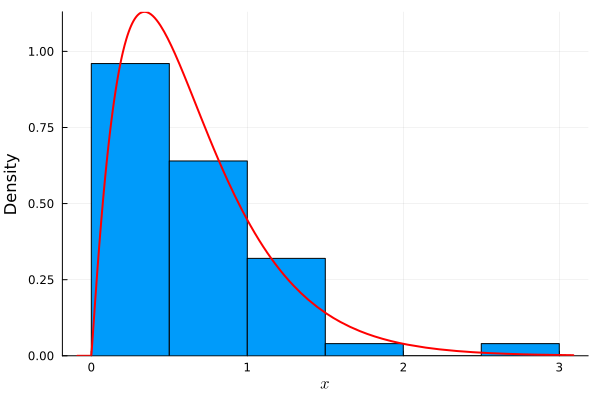

In [10]:
x = rand(Gamma(2, 1/3), 50)
fit0 = fit(Gamma, x)
histogram(x, normalize = true, xlabel = L"x", ylabel = "Density", bins = 8 ,label = "")
plot!(x->pdf(Gamma(fit0.α, fit0.θ), x), color = "red", lw = 2, label = "")

<div style="text-align: justify;">


In the same example, we may have a one-way classification with $n$ groups and $m$ observations per group. Then the example extends to

$$
X_{ij}\mid \lambda_i \sim \operatorname{Poisson}(\lambda_i), \qquad i=1,2,\ldots,n;\; j=1,2,\ldots,m;\ \text{independent},
$$

$$
\lambda_i \sim \operatorname{gamma}(\alpha,\beta), \qquad i=1,2,\ldots,n;\ \text{independent}.
$$

To estimate $\lambda_i$, we use the statistic $Y_i=\sum_{j=1}^m X_{ij}$, then $Y_i\mid \lambda_i \sim \operatorname{Poisson}(m\lambda_i)$, $i=1,2,\ldots,n$. The marginal pdf of $Y_i$ is

$$
\begin{aligned}
f(y_i)
&= \int_0^\infty f(y_i\mid \lambda_i)\,\pi(\lambda_i)\, d\lambda_i \\[6pt]
&= \int_0^\infty 
\frac{e^{-m\lambda_i}(m\lambda_i)^{y_i}}{y_i!} \;
\frac{e^{-\lambda_i/\beta}\lambda_i^{\alpha-1}}{\Gamma(\alpha)\beta^\alpha}\, d\lambda_i \\[6pt]
&= \int_0^\infty 
\frac{e^{-\lambda_i\left(m + \frac{1}{\beta}\right)}
\, m^{y_i}\lambda_i^{\,y_i+\alpha-1}}
{y_i!\,\beta^\alpha\,\Gamma(\alpha)}\, d\lambda_i \\[6pt]
&= 
\frac{m^{y_i}}{y_i!\,\beta^\alpha\,\Gamma(\alpha)}
\left(m + \frac{1}{\beta}\right)^{-(y_i+\alpha)}
\Gamma(y_i+\alpha) \\[6pt]
&= 
\frac{\Gamma(y_i+\alpha)}{\Gamma(y_i+1)\Gamma(\alpha)}
\left(\frac{m\beta}{m\beta+1}\right)^{y_i}
\left(\frac{1}{m\beta+1}\right)^{\alpha} \\[6pt]
&= 
\binom{y_i+\alpha-1}{y_i}
\left(\frac{1}{m\beta+1}\right)^{\alpha}
\left(1-\frac{1}{m\beta+1}\right)^{y_i}.
\end{aligned}
$$

So,  
$$
Y_i \sim \mathrm{NB}\!\left(\alpha,\; \frac{1}{m\beta+1}\right), \qquad i=1,2,\ldots,n.
$$

The posterior distribution of $\lambda_i$ is

$$
\begin{aligned}
\pi(\lambda_i \mid y_i)
&= \frac{f(y_i \mid \lambda_i)\,\pi(\lambda_i)}{f(y_i)} \\[6pt]
&= \frac{
\dfrac{e^{-m\lambda_i}(m\lambda_i)^{y_i}}{y_i!}\;
\dfrac{e^{-\lambda_i/\beta}\lambda_i^{\alpha-1}}{\beta^\alpha \Gamma(\alpha)}
}{f(y_i)} \\[10pt]
&= \frac{
\lambda_i^{\,y_i+\alpha-1}
e^{-\lambda_i\left(m + \frac{1}{\beta}\right)}
\left(m+\frac{1}{\beta}\right)^{y_i+\alpha}
}{\Gamma(y_i+\alpha)} .
\end{aligned}
$$

which shows that  

$$
\lambda_i \mid y_i \sim \mathrm{gamma}\!\left(y_i+\alpha,\; \left(m+\frac{1}{\beta}\right)^{-1}\right).
$$

The posterior mean (Bayes estimator) is

$$
\begin{aligned}
\hat{\lambda}_{iB}
&= \mathbb{E}(\lambda_i \mid y_i) \\[6pt]
&= (y_i+\alpha)\left(m+\frac{1}{\beta}\right)^{-1} \\[6pt]
&= \left(\sum_{j=1}^m x_{ij} + \alpha\right)
\left(m+\frac{1}{\beta}\right)^{-1} \\[6pt]
&= \left(\frac{m\beta}{1+m\beta}\right)\bar{X}_i
   + \left(\frac{1}{1+m\beta}\right)(\alpha\beta).
\end{aligned}
$$

Thus, $\hat{\lambda}_{iB}$ is a linear combination of the prior mean and sample mean.  
The variance of $\hat{\lambda}_{iB}$ is given by

$$
\begin{aligned}
\mathrm{Var}_{\lambda_i}(\hat{\lambda}_{iB})
&= \left( \frac{m\beta}{1+m\beta} \right)^{2}
\mathrm{Var}_{\lambda_i}(\bar{X}_i), \\[6pt]
&= \left( \frac{m\beta}{1+m\beta} \right)^{2}
\left( \frac{\lambda_i}{m} \right).
\end{aligned}
$$

With no surprise, for large $m$, the above expression is close to the variance of maximum likelihood estimator $\left(\dfrac{m\beta}{m\beta+1} \to 1 \text{ for large } m\right)$.

</div>

# Example - V (Gamma prior for Exponential rate parameter)

<div style="text-align: justify;">

Let $Y_1, Y_2, \cdots, Y_n$ be a observed random sample of size $n$ such that

$$
Y_i \mid \lambda \sim \text{exponential}(\lambda), \quad i = 1,2,\cdots,n,\ \text{independent}.
$$

Suppose that $\lambda$ has a $\text{gamma}(\alpha,\beta)$ distribution, which is the conjugate family for Exponential. So, the statistical model has the following hierarchy

$$
Y_i \mid \lambda \sim \text{exponential}(\lambda), \quad i = 1,2,\cdots,n,
$$

$$
\lambda \sim \text{gamma}(\alpha,\beta),
$$

where $\alpha$ and $\beta$ are known. Now, our interest is to estimate the $\lambda$ based on observed sample. The prior distribution of $\lambda$ is given by,

$$
\pi(\lambda)=\frac{e^{-\frac{\lambda}{\beta}}\lambda^{\alpha-1}}{\Gamma(\alpha)\beta^{\alpha}},\quad \lambda>0,
$$

where $\alpha$ and $\beta$ are positive constants. First, we shall estimate the posterior distribution of $\lambda$. We start with statistic $Z=\sum_{i=1}^{n}Y_i$. Sampling distribution of $Z$ is $\text{gamma}(n,\lambda)$ and it is denoted by $f(z\mid\lambda)$. The posterior distribution of $\lambda$ given the sample $Y_1,Y_2,\cdots,Y_n$, that is given $Z=z$, is

$$
\pi(\lambda\mid z)=\frac{f(z\mid\lambda)\pi(\lambda)}{f(z)}.
$$


where $f(z)$ is the marginal distribution of $Z$, and calculated as follows;

$$
\begin{aligned}
f(z) &= \int_{0}^{\infty} f(z \mid \lambda)\,\pi(\lambda)\, d\lambda \\[6pt]
&= \int_{0}^{\infty} \frac{z^{\,n-1} e^{-\lambda z} \lambda^{n}}{\Gamma(n)} \, \frac{\lambda^{\alpha-1} e^{-\frac{\lambda}{\beta}}}{\Gamma(\alpha)\beta^{\alpha}} \, d\lambda \\[6pt]
&= \frac{z^{\,n-1}}{\Gamma(n)\Gamma(\alpha)\beta^{\alpha}} \int_{0}^{\infty} e^{-\lambda\left(z+\frac{1}{\beta}\right)} \lambda^{\alpha+n-1} d\lambda \\[6pt]
&= \frac{z^{\,n-1}\Gamma(\alpha+n)}{\Gamma(n)\Gamma(\alpha)\beta^{\alpha}\left(z+\frac{1}{\beta}\right)^{\alpha+n}} \\[6pt]
&= \frac{z^{\,n-1}\Gamma(\alpha+n)}{\Gamma(n)\Gamma(\alpha)\beta^{\alpha}\left(z+\frac{1}{\beta}\right)^{\alpha+n}},
\end{aligned}
$$

where,

$$
\int_{0}^{\infty} 
\frac{\lambda^{\alpha+n-1} e^{-\lambda\left(z+\frac{1}{\beta}\right)}\left(z+\frac{1}{\beta}\right)^{\alpha+n}}
{\Gamma(\alpha+n)} \, d\lambda = 1.
$$

Because it is pdf of gamma(α + n, (z + 1/β)^(-1)) distribution. So integral reduces to 1. Now, posterior density π(λ|z) becomes,

$$
\begin{aligned}
\pi(\lambda \mid z)
&= \frac{f(z \mid \lambda)\,\pi(\lambda)}{f(z)} \\[6pt]
&= \frac{z^{n-1} e^{-\lambda z} \lambda^{n}}{\Gamma(n)}
   \frac{e^{-\lambda/\beta}\lambda^{\alpha-1}}{\Gamma(\alpha)\beta^\alpha}
   \frac{\Gamma(n)\Gamma(\alpha)(z + 1/\beta)^{\alpha+n}}{z^{n-1}\Gamma(\alpha+n)} \\[6pt]
&= \frac{e^{-\lambda(z + 1/\beta)} \lambda^{\alpha+n-1} (z + 1/\beta)^{\alpha+n}}
        {\Gamma(\alpha + n)}, \qquad 0 < \lambda < \infty.
\end{aligned}
$$

Hence, the posterior distribution of λ,
$$
\lambda \mid z \sim \text{gamma}\left(\alpha + n,\,(z + 1/\beta)^{-1}\right).
$$

Hence, the posterior distribution of $\lambda$, 
$$
\lambda \mid z \sim \text{gamma}\left(\alpha + n,\,(z + 1/\beta)^{-1}\right).
$$

So exact posterior mean $E(\lambda \mid z)$ is

$$
\frac{\alpha + n}{z + 1/\beta}
= \frac{\alpha + n}{n\bar{y} + 1/\beta}.
$$

Now, we approximate the posterior mean of $\lambda$ using a Monte Carlo (MC) sample, given $m$ independent values drawn directly from  
$\text{gamma}(\alpha + n,\; n\bar{y} + 1/\beta)$ posterior distribution.

Further, the accuracy of the Monte Carlo approximation is compared with respect to the exact posterior distribution. First, we generated $y$ of size $n = 50$ from exponential distribution with parameter $\lambda$, where $\lambda$ was generated from $\text{gamma}(\alpha = 8,\; \beta = 4)$ density distribution.To generate the independent values of $\lambda$ of the MC sample from the known posterior distribution, the Julia function  `rand(Gamma(shape, scale))` from `Distribution.jl` package


</div>

In [11]:
using Plots, Statistics, StatsBase
using LaTeXStrings, Distributions, Random
using KernelDensity, SpecialFunctions

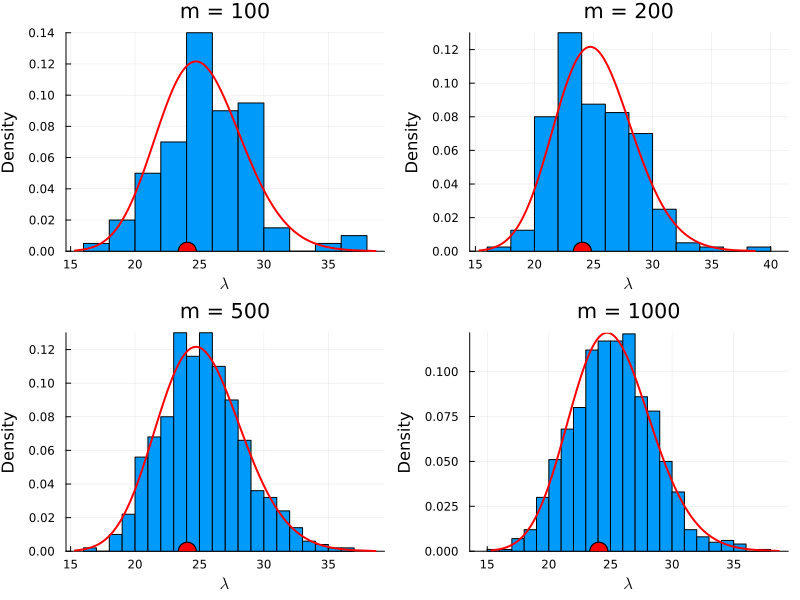

In [12]:
Random.seed!(123)
n = 50
α = 8
β = 4
λ = rand(Gamma(α, β))
y = rand(Exponential(1/λ), n)
p_α = α + n
p_β = (1/β) + n*mean(y)
p_mean = p_α/p_β

plt = plot(layout = (2, 2), size = (800, 600))
M = [100, 200, 500, 1000]

for (idx, m) in enumerate(M) 
    z1 = rand(Gamma(p_α, 1/p_β), m)
    histogram!(z1, normalize = true,  title = "m = $m", xlabel = L"λ", 
        ylabel = "Density", label = "", subplot = idx)
    plot!(x->pdf(Gamma(p_α, 1/p_β), x), color = "red", lw = 2, label = "", 
        subplot = idx)
    scatter!([λ], [0], color = "red", markersize = 10, label = "", subplot = idx)
end

display(plt)

<div style="text-align: justify;">

Figure: Histogram approximation of the posterior probability density of $\lambda$ for different posterior sample of size. Red dot indicates the exact posterior mean (given data). Red colored curve represents the exact posterior density function

</div>